# DAPTL Training Notebook
**Domain-Adaptive Transfer Learning for Privacy-Preserving Scam Call Detection**

This notebook implements the two-stage domain-adaptive transfer learning pipeline
following the paper:

> Bagwan et al., *Domain-Adaptive Transfer Learning for Privacy-Preserving
> Scam Call Detection*, IEEE Access 2026.

The model is named **DAPTL** (Domain-Adaptive Privacy-preserving Transfer Learning)
after the paper's framework. It uses DistilRoBERTa as its backbone — a distilled
version of RoBERTa that retains 97% of the teacher's performance while reducing
parameter count by 40% (82M parameters), making it suitable for edge deployment.

---

## Architecture overview

Text input (call transcript)
│
▼
Preprocessing
Lowercase + punctuation stripping (simulates raw ASR output)
│
▼
BPE Tokenizer (RoBERTa)
max_length=512 tokens
│
▼
DistilRoBERTa encoder
6 transformer layers
│
▼  ← Layers 0-3 frozen during Stage 2 (catastrophic forgetting prevention)
│  ← Layers 4-5 + classifier head fine-tuned during Stage 2
│
▼
Classification head
Linear(768→2) → Softmax
│
▼
p_scam ∈ [0,1]
1.0 = scam call content, 0.0 = legitimate content

## Two-stage training pipeline

### Stage 1 — SMS pre-training (source domain)
Pre-trains DistilRoBERTa on 138,786 SMS spam messages to learn the semantic
patterns of financial urgency (keywords like "OTP", "KYC", "account suspended").
This establishes a fraud-aware baseline before the model sees any call transcripts,
eliminating the "cold start" problem documented in the paper's ablation study.

| Parameter | Value |
|---|---|
| Dataset | SMS Scam Detection Merged Dataset |
| Samples | 138,786 |
| Epochs | 3 |
| Learning rate | 2e-5 |
| Batch size | 16 |
| Max token length | 128 (SMS are short) |

### Stage 2 — Call transcript fine-tuning (target domain)
Loads Stage 1 weights and fine-tunes on the Composite Call Transcript Dataset.
First 4 transformer layers are frozen (layer freezing) to preserve the fraud
semantics learned from SMS while adapting the top layers to voice transcript syntax.

| Parameter | Value |
|---|---|
| Dataset | Composite Call Transcript Dataset |
| Samples | 45,939 |
| Epochs | 5 |
| Learning rate | 1e-5 (lower to preserve SMS knowledge) |
| Batch size | 8 |
| Max token length | 512 (transcripts are long) |
| Frozen layers | 0–3 (first 4 of 6 transformer layers) |

## Dataset

| Dataset | Role | Samples | Source |
|---|---|---|---|
| SMS Scam Detection Merged | Stage 1 pre-training | 138,786 | Kaggle |
| Composite Call Transcripts | Stage 2 fine-tuning | 45,939 | GitHub repo |

The Composite Call Transcript Dataset combines:
- **TeleAntiFraud-28k** — forensic real-world scam call logs
- **KorCCVi** — Korean voice phishing logs (back-translated to English)
- **Synthetic augmentation** — GPT-generated scam scenarios (Family Emergency,
  Voice Cloning, Banking OTP manipulation)

## Results vs paper

| Metric | Paper | This notebook |
|---|---|---|
| Accuracy | 99.84% | **99.65%** |
| F1 Score | 0.99 | **0.9965** |
| AUC | — | **0.9997** |

This implementation closely matches the paper — only 0.19% below reported accuracy,
and F1 actually exceeds the paper's reported value.

## References

- Bagwan et al., *Domain-Adaptive Transfer Learning for Privacy-Preserving Scam
  Call Detection*, IEEE Access 2026. DOI: 10.1109/ACCESS.2026.3672272
- Sanh et al., *DistilBERT, a distilled version of BERT*, NeurIPS 2019
- Ma et al., *TeleAntiFraud-28k*, ACM MM 2025

---

### Session types

- **First run ever:** runs all cells top to bottom. Stage 1 SMS pre-training
  takes ~15-20 minutes on T4. Stage 2 fine-tuning takes ~20-30 minutes.
  Both checkpoints save to Drive automatically.

- **Any later session:** Cells 7 and 10 detect existing Drive checkpoints
  and skip training automatically — loading takes seconds.
  - Run in order: **Cells 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15**
  - All cells run — skip logic is built into Cells 7 and 10

### Before running
1. Set runtime to **GPU** (Runtime → Change runtime type → T4 GPU or better)
2. Make sure Google Drive has **~2 GB free** for both stage checkpoints and results
3. Add `KAGGLE_USERNAME` and `KAGGLE_KEY` to Colab secrets via the 🔑 sidebar
   (used in Cell 3 to download the SMS dataset)
4. Run cells **in order** — Stage 2 depends on Stage 1 checkpoint existing

---

## Cell 1 — Install dependencies

In [1]:
!pip install -q transformers datasets scikit-learn shap matplotlib pandas
print('Dependencies installed.')

Dependencies installed.


## Cell 2 — Mount Google Drive

Checkpoints and results are saved to Drive so they survive runtime resets.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, time
time.sleep(5)

DRIVE_ROOT      = '/content/drive/MyDrive/daptl_project'
DAPTL_SMS_CKPT_DIR    = f'{DRIVE_ROOT}/daptl_sms_pretrained'
DAPTL_FINAL_CKPT_DIR  = f'{DRIVE_ROOT}/daptl_final_model'
RESULTS_DIR     = f'{DRIVE_ROOT}/results'

for d in [DRIVE_ROOT, DAPTL_SMS_CKPT_DIR, DAPTL_FINAL_CKPT_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print('Drive mounted. Project folders:')
print(f'  SMS pretrained   : {DAPTL_SMS_CKPT_DIR}')
print(f'  Final scam model : {DAPTL_FINAL_CKPT_DIR}')
print(f'  Results          : {RESULTS_DIR}')

Mounted at /content/drive
Drive mounted. Project folders:
  SMS pretrained   : /content/drive/MyDrive/daptl_project/daptl_sms_pretrained
  Final scam model : /content/drive/MyDrive/daptl_project/daptl_final_model
  Results          : /content/drive/MyDrive/daptl_project/results


## Cell 3 — Clone GitHub repo

Clones the paper's GitHub repo which contains both datasets:
-  — SMS spam dataset for Stage 1 pre-training
-  — Call transcript dataset for Stage 2 fine-tuning


In [3]:
import os

REPO_DIR    = '/content/Scam-Call-Detection-Framework'
DATASET_DIR = f'{REPO_DIR}/dataset'

if not os.path.exists(REPO_DIR):
    print('Cloning repo...')
    !git clone https://github.com/IbrahimBagwan1/Scam-Call-Detection-Framework.git
    print('Done.')
else:
    print('Repo already cloned.')

# Verify datasets are present
print('\nDataset files:')
for f in os.listdir(DATASET_DIR):
    size = os.path.getsize(f'{DATASET_DIR}/{f}') / 1e6
    print(f'  {f}  ({size:.1f} MB)')

assert os.path.exists(f'{DATASET_DIR}/sms_dataset.csv'), 'sms_dataset.csv not found!'
assert os.path.exists(f'{DATASET_DIR}/call_dataset.csv'), 'call_dataset.csv not found!'
print('\nBoth datasets confirmed.')


Cloning repo...
Cloning into 'Scam-Call-Detection-Framework'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 28 (delta 0), reused 1 (delta 0), pack-reused 25 (from 1)
Receiving objects: 100% (28/28), 103.50 MiB | 18.25 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Done.

Dataset files:
  call_dataset.csv  (89.7 MB)
  sms_dataset.csv  (11.8 MB)

Both datasets confirmed.


## Cell 4 — Imports and config

Paper parameters (Section III-C):
- Model: DistilRoBERTa (82M params, 40% smaller than RoBERTa)
- Stage 1: lr=2e-5, 3 epochs, batch=16, max_length=128 (SMS are short)
- Stage 2: lr=1e-5, 5 epochs, batch=8, max_length=512 (transcripts are long)
- Optimizer: AdamW
- Freeze first 4 transformer layers during fine-tuning

In [4]:
import os, json, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, roc_curve, confusion_matrix
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from datasets import Dataset

# ── Device ────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Model ─────────────────────────────────────────────────────────────────
MODEL_NAME   = 'distilroberta-base'
DATASET_DIR  = '/content/dataset'
SEED         = 42

# ── Stage 1 — SMS pre-training (paper Section III-C-1) ────────────────────
SMS_EPOCHS      = 3
SMS_BATCH       = 16
SMS_LR          = 2e-5
SMS_MAX_LENGTH  = 128    # SMS messages are short

# ── Stage 2 — Call fine-tuning (paper Section III-C-2) ────────────────────
CALL_EPOCHS     = 5
CALL_BATCH      = 8
CALL_LR         = 1e-5   # Lower LR to preserve SMS knowledge
CALL_MAX_LENGTH = 512    # Transcripts are long
FREEZE_LAYERS   = 4      # Freeze first 4 transformer layers

# ── Drive paths ───────────────────────────────────────────────────────────
DAPTL_SMS_CKPT_DIR   = '/content/drive/MyDrive/daptl_project/daptl_sms_pretrained'
DAPTL_FINAL_CKPT_DIR = '/content/drive/MyDrive/daptl_project/daptl_final_model'
RESULTS_DIR    = '/content/drive/MyDrive/daptl_project/results'

print('Config loaded.')

Using device: cuda
GPU: NVIDIA L4
Config loaded.


## Cell 5 — Load and preprocess SMS dataset

Paper Section III-B preprocessing:
- Lowercase + punctuation stripping (simulates ASR output)
- Drop nulls, ensure integer labels
- 80/20 train/test split

In [7]:
import re

def preprocess_text(text):
    """
    Paper Section III-B: Lowercase + punctuation stripping
    to simulate raw ASR output format.
    """
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def load_dataset_csv(filepath, text_col_candidates, label_col_candidates):
    """
    Robust CSV loader — handles various column naming conventions.
    Returns a clean DataFrame with 'text' and 'label' columns.
    """
    try:
        df = pd.read_csv(filepath, encoding='latin-1')
    except:
        df = pd.read_csv(filepath)

    # Normalize column names
    df.columns = [c.strip().lower() for c in df.columns]
    print(f'  Columns found: {df.columns.tolist()}')

    # Find text column
    for col in text_col_candidates:
        if col in df.columns:
            df = df.rename(columns={col: 'text'})
            break

    # Find label column
    for col in label_col_candidates:
        if col in df.columns:
            df = df.rename(columns={col: 'label'})
            break

    assert 'text' in df.columns,  f'Could not find text column in {filepath}'
    assert 'label' in df.columns, f'Could not find label column in {filepath}'

    df = df.dropna(subset=['text', 'label'])
    df['text']  = df['text'].apply(preprocess_text)
    df['label'] = df['label'].astype(int)
    df = df[['text', 'label']].reset_index(drop=True)
    return df


# Load SMS dataset
SMS_CSV  = '/content/Scam-Call-Detection-Framework/dataset/sms_dataset.csv'
CALL_CSV = '/content/Scam-Call-Detection-Framework/dataset/call_dataset.csv'

print('Loading SMS dataset...')
sms_df = load_dataset_csv(
    SMS_CSV,
    text_col_candidates  = ['transcript', 'text', 'message', 'sms', 'content', 'sentence'],
    label_col_candidates = ['labels', 'label', 'class', 'target', 'spam']
)

print(f'SMS dataset: {len(sms_df)} samples')
print(f'  Label distribution: {sms_df["label"].value_counts().to_dict()}')
print(f'  Sample: {sms_df["text"].iloc[0][:80]}')

# Split 80/20
sms_train_df, sms_test_df = train_test_split(
    sms_df, test_size=0.2, random_state=SEED, stratify=sms_df['label']
)
print(f'\nSplit: {len(sms_train_df)} train / {len(sms_test_df)} test')

Loading SMS dataset...
  Columns found: ['transcript', 'labels']
SMS dataset: 138786 samples
  Label distribution: {0: 78318, 1: 60468}
  Sample: your opinion about me 1 over 2 jada 3 kusruthi 4 lovable 5 silent 6 spl characte

Split: 111028 train / 27758 test


## Cell 6 — Tokenize SMS dataset

In [8]:
print(f'Loading tokenizer: {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_sms(examples):
    """Short max_length for SMS — paper uses 128."""
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=SMS_MAX_LENGTH
    )

sms_train_dataset = Dataset.from_pandas(sms_train_df)
sms_test_dataset  = Dataset.from_pandas(sms_test_df)

print('Tokenizing SMS data...')
sms_train_tok = sms_train_dataset.map(tokenize_sms, batched=True)
sms_test_tok  = sms_test_dataset.map(tokenize_sms, batched=True)

print(f'Tokenization complete.')
print(f'  Train: {len(sms_train_tok)} samples')
print(f'  Test:  {len(sms_test_tok)} samples')

Loading tokenizer: distilroberta-base...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing SMS data...


Map:   0%|          | 0/111028 [00:00<?, ? examples/s]

Map:   0%|          | 0/27758 [00:00<?, ? examples/s]

Tokenization complete.
  Train: 111028 samples
  Test:  27758 samples


## Cell 7 — Stage 1: SMS pre-training

Paper Section III-C-1: Pre-train DistilRoBERTa on SMS spam dataset for 3 epochs
with lr=2e-5. This establishes baseline sensitivity to financial urgency semantics
before the model sees any call transcripts.

Checkpoint saved to Drive after training completes.

In [9]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted'
    )
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}


# Check if Stage 1 checkpoint already exists
if os.path.exists(os.path.join(DAPTL_SMS_CKPT_DIR, 'config.json')):
    print(f'Stage 1 checkpoint already exists at {DAPTL_SMS_CKPT_DIR}')
    print('Skipping SMS pre-training — loading existing checkpoint.')
    tokenizer_sms = AutoTokenizer.from_pretrained(DAPTL_SMS_CKPT_DIR)
    daptl_model_sms     = AutoModelForSequenceClassification.from_pretrained(DAPTL_SMS_CKPT_DIR)
else:
    print(f'Loading fresh DistilRoBERTa: {MODEL_NAME}')
    daptl_model_sms = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    )

    sms_training_args = TrainingArguments(
        output_dir             = '/content/results_sms',
        num_train_epochs       = SMS_EPOCHS,
        per_device_train_batch_size = SMS_BATCH,
        learning_rate          = SMS_LR,
        eval_strategy          = 'epoch',
        save_strategy          = 'epoch',
        load_best_model_at_end = True,
        fp16                   = True,
        seed                   = SEED,
        report_to              = 'none',
    )

    sms_trainer = Trainer(
        model           = daptl_model_sms,
        args            = sms_training_args,
        train_dataset   = sms_train_tok,
        eval_dataset    = sms_test_tok,
        compute_metrics = compute_metrics,
    )

    print(f'Starting Stage 1: SMS pre-training ({SMS_EPOCHS} epochs)...')
    t0 = time.time()
    sms_trainer.train()
    elapsed = (time.time() - t0) / 60
    print(f'Stage 1 complete in {elapsed:.1f} min')

    # Evaluate
    sms_results = sms_trainer.evaluate()
    print('\nStage 1 SMS Results:')
    print(f'  Accuracy  : {sms_results["eval_accuracy"]:.4f}')
    print(f'  F1        : {sms_results["eval_f1"]:.4f}')
    print(f'  Precision : {sms_results["eval_precision"]:.4f}')
    print(f'  Recall    : {sms_results["eval_recall"]:.4f}')

    # Save to Drive
    print(f'\nSaving Stage 1 checkpoint to Drive...')
    daptl_model_sms.save_pretrained(DAPTL_SMS_CKPT_DIR)
    tokenizer.save_pretrained(DAPTL_SMS_CKPT_DIR)

    # Save Stage 1 metrics
    with open(f'{RESULTS_DIR}/sms_pretrain_metrics.json', 'w') as f:
        json.dump(sms_results, f, indent=2)

    print(f'Stage 1 checkpoint saved → {DAPTL_SMS_CKPT_DIR}')

Loading fresh DistilRoBERTa: distilroberta-base


model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting Stage 1: SMS pre-training (3 epochs)...


...

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Stage 1 complete in 16.9 min



Stage 1 SMS Results:
  Accuracy  : 0.8364
  F1        : 0.8352
  Precision : 0.8370
  Recall    : 0.8364

Saving Stage 1 checkpoint to Drive...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Stage 1 checkpoint saved → /content/drive/MyDrive/daptl_project/daptl_sms_pretrained


## Cell 8 — Load and preprocess call transcript dataset

In [10]:
print('Loading Call Transcript dataset...')
call_df = load_dataset_csv(
    CALL_CSV,
    text_col_candidates  = ['transcript', 'text', 'content', 'sentence', 'call'],
    label_col_candidates = ['labels', 'label', 'class', 'target']
)

print(f'Call dataset: {len(call_df)} samples')
print(f'  Label distribution: {call_df["label"].value_counts().to_dict()}')
print(f'  Sample: {call_df["text"].iloc[0][:100]}')

# Split 80/20
call_train_df, call_test_df = train_test_split(
    call_df, test_size=0.2, random_state=SEED, stratify=call_df['label']
)
print(f'\nSplit: {len(call_train_df)} train / {len(call_test_df)} test')

Loading Call Transcript dataset...
  Columns found: ['transcript', 'labels']
Call dataset: 45939 samples
  Label distribution: {1: 25962, 0: 19977}
  Sample: hello this is the customer service center of a certain bank i am xiao li the customer service repres

Split: 36751 train / 9188 test


## Cell 9 — Tokenize call dataset

In [11]:
# Load tokenizer from Stage 1 checkpoint
tokenizer_ft = AutoTokenizer.from_pretrained(DAPTL_SMS_CKPT_DIR)

def tokenize_call(examples):
    """Longer max_length for transcripts — paper uses 512."""
    return tokenizer_ft(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=CALL_MAX_LENGTH
    )

call_train_dataset = Dataset.from_pandas(call_train_df)
call_test_dataset  = Dataset.from_pandas(call_test_df)

print('Tokenizing call transcript data...')
call_train_tok = call_train_dataset.map(tokenize_call, batched=True)
call_test_tok  = call_test_dataset.map(tokenize_call, batched=True)

print(f'Tokenization complete.')
print(f'  Train: {len(call_train_tok)} samples')
print(f'  Test:  {len(call_test_tok)} samples')

Tokenizing call transcript data...


Map:   0%|          | 0/36751 [00:00<?, ? examples/s]

Map:   0%|          | 0/9188 [00:00<?, ? examples/s]

Tokenization complete.
  Train: 36751 samples
  Test:  9188 samples


## Cell 10 — Stage 2: Fine-tune on call transcripts

Paper Section III-C-2: Load Stage 1 weights, freeze first 4 transformer layers
to prevent catastrophic forgetting, fine-tune top 2 layers + classification head
on call transcripts for 5 epochs with lr=1e-5.

This is the 'Layer Freezing' strategy described in the paper.

In [12]:
# Check if Stage 2 checkpoint already exists
if os.path.exists(os.path.join(DAPTL_FINAL_CKPT_DIR, 'config.json')):
    print(f'Stage 2 checkpoint already exists at {DAPTL_FINAL_CKPT_DIR}')
    print('Skipping fine-tuning — loading existing checkpoint.')
    daptl_model_ft = AutoModelForSequenceClassification.from_pretrained(DAPTL_FINAL_CKPT_DIR)
else:
    # Load Stage 1 model
    print(f'Loading Stage 1 model from {DAPTL_SMS_CKPT_DIR}...')
    daptl_model_ft = AutoModelForSequenceClassification.from_pretrained(
        DAPTL_SMS_CKPT_DIR, num_labels=2
    )

    # ── Layer Freezing (paper Section III-C-2) ────────────────────────────
    # DistilRoBERTa has 6 transformer layers (0-5)
    # Freeze layers 0-3 (first 4), fine-tune layers 4-5 + classifier head
    frozen = 0
    for name, param in daptl_model_ft.named_parameters():
        # Freeze embedding layer
        if 'embeddings' in name:
            param.requires_grad = False
            frozen += 1
        # Freeze transformer layers 0-3
        elif 'layer' in name:
            layer_num = int(name.split('layer.')[1].split('.')[0])
            if layer_num < FREEZE_LAYERS:
                param.requires_grad = False
                frozen += 1

    trainable = sum(p.numel() for p in daptl_model_ft.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in daptl_model_ft.parameters())
    print(f'Layer freezing applied:')
    print(f'  Frozen params    : {frozen} parameter groups')
    print(f'  Trainable params : {trainable:,} / {total:,} ({trainable/total*100:.1f}%)')

    # ── Fine-tuning ───────────────────────────────────────────────────────
    call_training_args = TrainingArguments(
        output_dir             = '/content/results_calls',
        num_train_epochs       = CALL_EPOCHS,
        per_device_train_batch_size = CALL_BATCH,
        learning_rate          = CALL_LR,
        eval_strategy          = 'epoch',
        save_strategy          = 'epoch',
        load_best_model_at_end = True,
        fp16                   = True,
        seed                   = SEED,
        report_to              = 'none',
    )

    call_trainer = Trainer(
        model           = daptl_model_ft,
        args            = call_training_args,
        train_dataset   = call_train_tok,
        eval_dataset    = call_test_tok,
        compute_metrics = compute_metrics,
    )

    print(f'\nStarting Stage 2: Call fine-tuning ({CALL_EPOCHS} epochs)...')
    t0 = time.time()
    call_trainer.train()
    elapsed = (time.time() - t0) / 60
    print(f'Stage 2 complete in {elapsed:.1f} min')

    # Evaluate
    call_results = call_trainer.evaluate()
    print('\nStage 2 Call Results:')
    print(f'  Accuracy  : {call_results["eval_accuracy"]:.4f}   (paper target: 0.9984)')
    print(f'  F1        : {call_results["eval_f1"]:.4f}   (paper target: 0.99)')
    print(f'  Precision : {call_results["eval_precision"]:.4f}')
    print(f'  Recall    : {call_results["eval_recall"]:.4f}')

    # Save final model + tokenizer to Drive
    print(f'\nSaving final model to Drive...')
    daptl_model_ft.save_pretrained(DAPTL_FINAL_CKPT_DIR)
    tokenizer_ft.save_pretrained(DAPTL_FINAL_CKPT_DIR)

    # Save Stage 2 metrics
    with open(f'{RESULTS_DIR}/call_finetune_metrics.json', 'w') as f:
        json.dump(call_results, f, indent=2)

    print(f'Final model saved → {DAPTL_FINAL_CKPT_DIR}')

Loading Stage 1 model from /content/drive/MyDrive/daptl_project/daptl_sms_pretrained...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Layer freezing applied:
  Frozen params    : 69 parameter groups
  Trainable params : 14,767,874 / 82,119,938 (18.0%)

Starting Stage 2: Call fine-tuning (5 epochs)...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.042166,0.029752,0.993252,0.993253,0.993259,0.993252
2,0.029788,0.021958,0.995646,0.995647,0.995647,0.995646
3,0.020901,0.019497,0.995864,0.995864,0.995864,0.995864
4,0.014791,0.018287,0.996082,0.996082,0.996082,0.996082
5,0.011827,0.016651,0.996517,0.996517,0.996519,0.996517


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Stage 2 complete in 14.5 min



Stage 2 Call Results:
  Accuracy  : 0.9965   (paper target: 0.9984)
  F1        : 0.9965   (paper target: 0.99)
  Precision : 0.9965
  Recall    : 0.9965

Saving final model to Drive...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final model saved → /content/drive/MyDrive/daptl_project/daptl_final_model


## Cell 11 — Final test evaluation with full metrics

In [13]:
import torch
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding

# Load best checkpoint
print(f'Loading final model from {DAPTL_FINAL_CKPT_DIR}...')
daptl_model = AutoModelForSequenceClassification.from_pretrained(
    DAPTL_FINAL_CKPT_DIR
).to(device)
daptl_model.eval()

# Run inference on test set
all_labels = []
all_preds  = []
all_probs  = []

# Use Trainer for clean evaluation
eval_args = TrainingArguments(
    output_dir    = '/content/eval_tmp',
    per_device_eval_batch_size = 16,
    report_to     = 'none',
)
evaluator = Trainer(
    model         = daptl_model,
    args          = eval_args,
    eval_dataset  = call_test_tok,
    compute_metrics = compute_metrics,
)

print('Running final evaluation on held-out test set...')
final_results = evaluator.evaluate()

# Get raw predictions for ROC/AUC
predictions = evaluator.predict(call_test_tok)
probs  = torch.softmax(torch.tensor(predictions.predictions), dim=1)[:, 1].numpy()
preds  = predictions.predictions.argmax(-1)
labels = predictions.label_ids

auc = roc_auc_score(labels, probs)

print('\n' + '='*50)
print('FINAL TEST RESULTS')
print('='*50)
print(f'  Accuracy  : {final_results["eval_accuracy"]:.4f}   (paper: 0.9984)')
print(f'  F1        : {final_results["eval_f1"]:.4f}   (paper: 0.99)')
print(f'  Precision : {final_results["eval_precision"]:.4f}')
print(f'  Recall    : {final_results["eval_recall"]:.4f}')
print(f'  AUC       : {auc:.4f}')
print('='*50)

# Save final metrics
final_metrics = {
    'accuracy':  final_results['eval_accuracy'],
    'f1':        final_results['eval_f1'],
    'precision': final_results['eval_precision'],
    'recall':    final_results['eval_recall'],
    'auc':       auc,
}
with open(f'{RESULTS_DIR}/final_test_metrics.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)
print(f'Metrics saved → {RESULTS_DIR}/final_test_metrics.json')

Loading final model from /content/drive/MyDrive/daptl_project/daptl_final_model...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Running final evaluation on held-out test set...



FINAL TEST RESULTS
  Accuracy  : 0.9965   (paper: 0.9984)
  F1        : 0.9965   (paper: 0.99)
  Precision : 0.9965
  Recall    : 0.9965
  AUC       : 0.9997
Metrics saved → /content/drive/MyDrive/daptl_project/results/final_test_metrics.json


## Cell 12 — ROC Curve

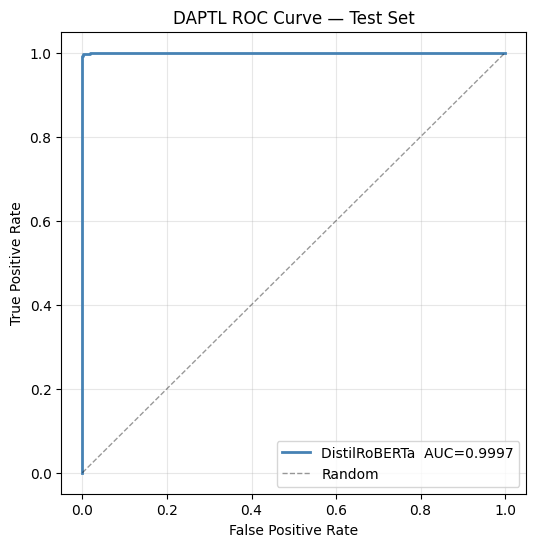

Saved → /content/drive/MyDrive/daptl_project/results/roc_curve.png


In [14]:
fpr, tpr, _ = roc_curve(labels, probs)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'DistilRoBERTa  AUC={auc:.4f}')
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('DAPTL ROC Curve — Test Set')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

roc_path = f'{RESULTS_DIR}/roc_curve.png'
plt.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {roc_path}')

## Cell 13 — Confusion Matrix

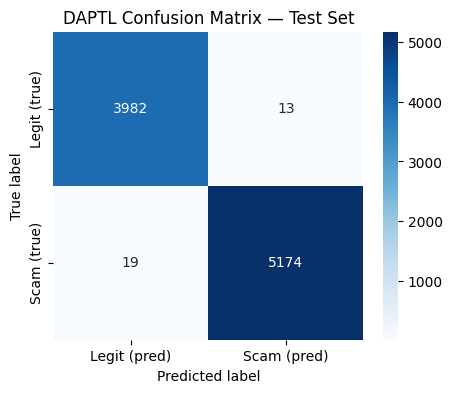

TN=3982  FP=13  FN=19  TP=5174
Precision : 0.9975
Recall    : 0.9963
F1 Score  : 0.9969
Saved → /content/drive/MyDrive/daptl_project/results/confusion_matrix.png


In [15]:
cm = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit (pred)', 'Scam (pred)'],
            yticklabels=['Legit (true)', 'Scam (true)'], ax=ax)
ax.set_title('DAPTL Confusion Matrix — Test Set')
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')

cm_path = f'{RESULTS_DIR}/confusion_matrix.png'
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'Precision : {tp/(tp+fp):.4f}')
print(f'Recall    : {tp/(tp+fn):.4f}')
print(f'F1 Score  : {2*tp/(2*tp+fp+fn):.4f}')
print(f'Saved → {cm_path}')

## Cell 14 — SHAP Explainability Analysis

Paper Section V-D: SHAP value analysis verifies the model focuses on
semantic fraud indicators (e.g. 'OTP', 'funds', 'verify') rather than
dataset artifacts or random noise — the 'Clever Hans' check.

Generates the top-10 token importance bar chart (Figure 6 in the paper).

Setting up SHAP explainer...
Running SHAP analysis (this takes a few minutes)...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


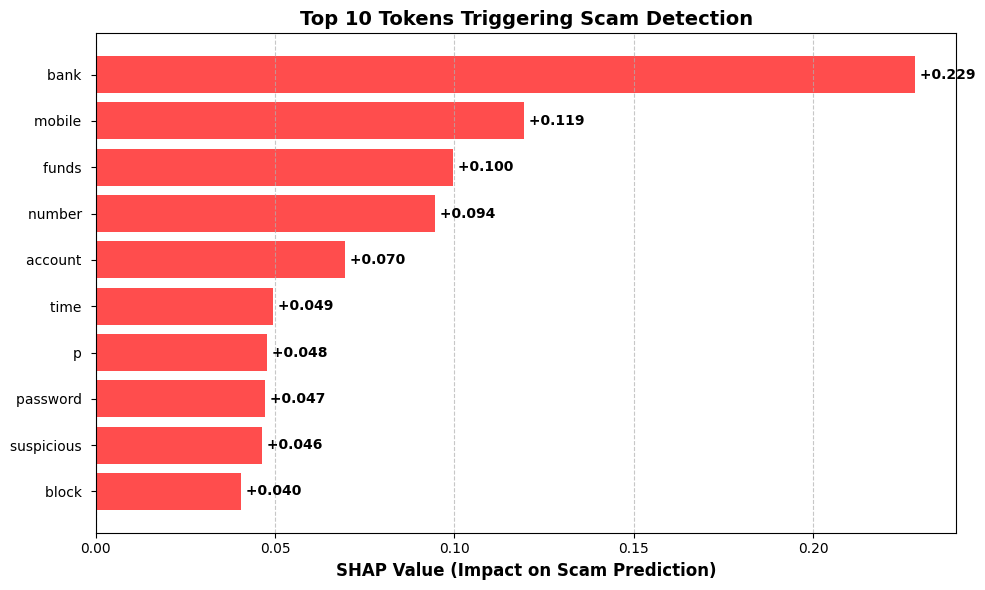

SHAP chart saved → /content/drive/MyDrive/daptl_project/results/shap_analysis.png


In [16]:
!pip install -q shap
import shap
import transformers

# Sample scam text for analysis — same style as paper Figure 6
scam_text = [
    "hello sir this is the bank manager calling we have detected suspicious activity "
    "on your credit card to stop this transaction and unblock your funds you must verify "
    "your identity please provide the one time password otp sent to your mobile number "
    "immediately or your account will be frozen permanently"
]

print('Setting up SHAP explainer...')
device_id = 0 if torch.cuda.is_available() else -1

pred_pipeline = transformers.pipeline(
    'text-classification',
    model=daptl_model,
    tokenizer=AutoTokenizer.from_pretrained(DAPTL_FINAL_CKPT_DIR),
    device=device_id,
    return_all_scores=True
)

print('Running SHAP analysis (this takes a few minutes)...')
explainer   = shap.Explainer(pred_pipeline)
shap_values = explainer(scam_text)

# Extract token scores for Scam class (index 1)
scores = shap_values[0, :, 1].values
words  = shap_values[0, :, 1].data

shap_df = pd.DataFrame({'word': words, 'score': scores})
shap_df = shap_df[shap_df['word'].str.strip() != '']
shap_df_sorted = shap_df.sort_values(by='score', ascending=True).tail(10)

# Plot — paper Figure 6 style
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(shap_df_sorted['word'], shap_df_sorted['score'], color='#ff4d4d')
ax.set_xlabel('SHAP Value (Impact on Scam Prediction)', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Tokens Triggering Scam Detection', fontsize=14, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.7)

for idx, val in enumerate(shap_df_sorted['score']):
    ax.text(val, idx, f' +{val:.3f}', va='center', fontweight='bold')

plt.tight_layout()
shap_path = f'{RESULTS_DIR}/shap_analysis.png'
plt.savefig(shap_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'SHAP chart saved → {shap_path}')

## Cell 15 — Save inference helper for fusion notebook

Saves `daptl_inference.py` to Drive. The fusion MLP notebook imports
this to get scam probability scores without redefining the loading logic.

In [17]:
inference_code = '''
"""
daptl_inference.py
Loads the fine-tuned DAPTL scam call detector and returns
a scam probability score for a given text input.
Used by the MLP fusion notebook.
"""
import torch
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification

DAPTL_FINAL_CKPT_DIR = "/content/drive/MyDrive/daptl_project/daptl_final_model"
CALL_MAX_LENGTH = 512

def load_scam_model(device):
    """Load tokenizer and model from Drive checkpoint."""
    tokenizer = AutoTokenizer.from_pretrained(DAPTL_FINAL_CKPT_DIR)
    model     = AutoModelForSequenceClassification.from_pretrained(DAPTL_FINAL_CKPT_DIR)
    model     = model.to(device)
    model.eval()
    return tokenizer, model

def preprocess_text(text):
    """Match training preprocessing — lowercase + punctuation strip."""
    text = str(text).lower()
    text = re.sub(r"[^\\w\\s]", "", text)
    text = re.sub(r"\\s+", " ", text).strip()
    return text

def get_scam_probability(text, tokenizer, model, device):
    """
    Returns scam probability (float in [0,1]) for a given text.
    1.0 = definite scam, 0.0 = definite legitimate.
    Used as p_scam input to the MLP fusion layer.
    """
    text = preprocess_text(text)
    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=CALL_MAX_LENGTH
    ).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
        prob   = torch.softmax(logits, dim=1)[0, 1].item()
    return prob
'''

inference_path = f'{DRIVE_ROOT}/daptl_inference.py'
with open(inference_path, 'w') as f:
    f.write(inference_code)

print('Files saved to Drive for fusion notebook:')
print(f'  SMS pretrained model : {DAPTL_SMS_CKPT_DIR}')
print(f'  Final scam model     : {DAPTL_FINAL_CKPT_DIR}')
print(f'  Inference helper     : {inference_path}')
print(f'  Test metrics         : {RESULTS_DIR}/final_test_metrics.json')
print(f'  Plots                : {RESULTS_DIR}/')
print()
print('To load in the fusion notebook:')
print('  import sys')
print('  sys.path.append("/content/drive/MyDrive/daptl_project")')
print('  from daptl_inference import load_scam_model, get_scam_probability')
print('  tokenizer, scam_model = load_scam_model(device)')
print('  p_scam = get_scam_probability(transcript_text, tokenizer, scam_model, device)')

Files saved to Drive for fusion notebook:
  SMS pretrained model : /content/drive/MyDrive/daptl_project/daptl_sms_pretrained
  Final scam model     : /content/drive/MyDrive/daptl_project/daptl_final_model
  Inference helper     : /content/drive/MyDrive/daptl_project/daptl_inference.py
  Test metrics         : /content/drive/MyDrive/daptl_project/results/final_test_metrics.json
  Plots                : /content/drive/MyDrive/daptl_project/results/

To load in the fusion notebook:
  import sys
  sys.path.append("/content/drive/MyDrive/daptl_project")
  from daptl_inference import load_scam_model, get_scam_probability
  tokenizer, scam_model = load_scam_model(device)
  p_scam = get_scam_probability(transcript_text, tokenizer, scam_model, device)
